## 1. Dataset Inspection

In [2]:
import os

DATASET_DIR = r"C:\Users\Hewlett Packard\Downloads\Traffic Flow Forecasting"

print("Dataset folder exists:", os.path.exists(DATASET_DIR))
print("\nFiles in dataset folder:")

for file in os.listdir(DATASET_DIR):
    file_path = os.path.join(DATASET_DIR, file)
    print(file, " | Size:", round(os.path.getsize(file_path) / (1024 * 1024), 2), "MB")

Dataset folder exists: True

Files in dataset folder:
trafficflowforecasting-1  | Size: 0.0 MB
tra_adj_mat.csv  | Size: 0.0 MB
tra_Y_te.csv  | Size: 0.53 MB
tra_Y_tr.csv  | Size: 0.79 MB


## 2. Load Dataset

In [3]:
import pandas as pd
import numpy as np

DATASET_DIR = r"C:\Users\Hewlett Packard\Downloads\Traffic Flow Forecasting"

train_df = pd.read_csv(
    os.path.join(DATASET_DIR, "tra_Y_tr.csv")
)

test_df = pd.read_csv(
    os.path.join(DATASET_DIR, "tra_Y_te.csv")
)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nTraining data:")
display(train_df.head())

print("\nTesting data:")
display(test_df.head())

Training shape: (36, 1261)
Testing shape: (36, 840)

Training data:


,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var1252,Var1253,Var1254,Var1255,Var1256,Var1257,Var1258,Var1259,Var1260,Var1261
0,0.050911,0.047641,0.044839,0.059785,0.062588,0.063989,0.088277,0.113498,0.122840,0.125175,...,0.071462,0.080336,0.098085,0.147595,0.184960,0.248015,0.260159,0.371322,0.424568,0.422700
1,0.046240,0.049510,0.052312,0.046707,0.057450,0.055582,0.077534,0.094348,0.097151,0.107426,...,0.054180,0.081738,0.074731,0.120504,0.189164,0.254554,0.274638,0.370855,0.438113,0.501168
2,0.050444,0.044372,0.050444,0.050444,0.043438,0.066791,0.069127,0.070061,0.095750,0.079869,...,0.044372,0.068660,0.072863,0.104157,0.152732,0.200374,0.257356,0.255021,0.401681,0.379262
3,0.044839,0.038300,0.051378,0.050444,0.045773,0.048108,0.056983,0.059785,0.077534,0.077534,...,0.054647,0.070995,0.073797,0.098085,0.153199,0.205044,0.268099,0.302195,0.403550,0.393274
4,0.044839,0.053246,0.056516,0.049043,0.041569,0.049977,0.047641,0.065390,0.061653,0.063055,...,0.058851,0.053713,0.054647,0.068192,0.084073,0.119570,0.136385,0.152265,0.197104,0.255021



Testing data:


,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var831,Var832,Var833,Var834,Var835,Var836,Var837,Var838,Var839,Var840
0,0.401681,0.380196,0.355441,0.347501,0.375525,0.342830,0.401681,0.413825,0.384400,0.373190,...,0.153199,0.143858,0.112564,0.104157,0.078001,0.076133,0.056516,0.052312,0.055582,0.042036
1,0.573097,0.619337,0.589911,0.667445,0.618403,0.626810,0.503036,0.440448,0.447454,0.439047,...,0.254087,0.224194,0.202242,0.162074,0.142457,0.113498,0.099019,0.091079,0.071929,0.072396
2,0.397011,0.410089,0.363849,0.385801,0.346567,0.360579,0.323213,0.332555,0.346567,0.313872,...,0.172816,0.159738,0.113498,0.118636,0.134050,0.101355,0.078468,0.079402,0.060719,0.059318
3,0.463335,0.429239,0.428772,0.411023,0.426903,0.407753,0.404017,0.407286,0.417095,0.397478,...,0.253153,0.202242,0.164876,0.163942,0.144325,0.132181,0.117702,0.102289,0.083139,0.085007
4,0.284914,0.376927,0.395142,0.427837,0.421298,0.526390,0.500701,0.554414,0.527324,0.525455,...,0.432508,0.392807,0.311070,0.263895,0.262494,0.243344,0.198972,0.181224,0.141056,0.143391


## 3. Prepare Traffic Time Series

In [4]:
# Remove the CSV index column
train_values = train_df.iloc[:, 1:].values
test_values = test_df.iloc[:, 1:].values

# Calculate average traffic across all locations
train_traffic = train_values.mean(axis=0)
test_traffic = test_values.mean(axis=0)

print("Training time points:", len(train_traffic))
print("Testing time points:", len(test_traffic))

print("\nFirst 10 training traffic values:")
print(train_traffic[:10])

print("\nFirst 10 testing traffic values:")
print(test_traffic[:10])

Training time points: 1260
Testing time points: 839

First 10 training traffic values:
[0.06125123 0.06192589 0.06551975 0.06382013 0.07146193 0.07765063
 0.09314183 0.10270382 0.10516892 0.12443562]

First 10 testing traffic values:
[0.41915771 0.41854793 0.43906015 0.43624475 0.44576781 0.45804141
 0.45185272 0.44556023 0.44111007 0.4382298 ]


## 4. Visualize Traffic Flow

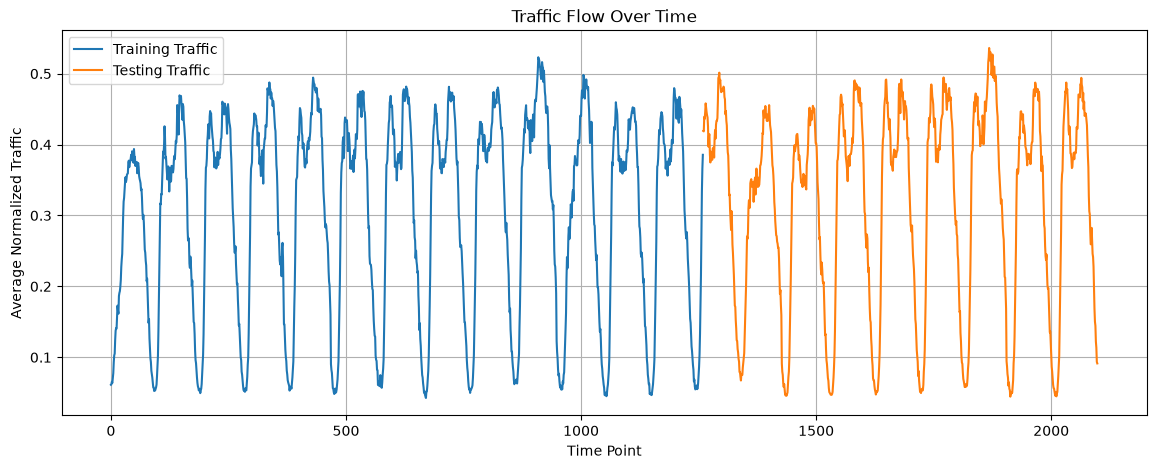

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(train_traffic, label="Training Traffic")
plt.plot(
    range(len(train_traffic), len(train_traffic) + len(test_traffic)),
    test_traffic,
    label="Testing Traffic"
)

plt.title("Traffic Flow Over Time")
plt.xlabel("Time Point")
plt.ylabel("Average Normalized Traffic")
plt.legend()
plt.grid(True)
plt.show()

## 5. Create Time-Series Features

In [6]:
def create_sequences(data, window_size=10):
    X = []
    y = []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])

    return np.array(X), np.array(y)


WINDOW_SIZE = 10

X_train, y_train = create_sequences(train_traffic, WINDOW_SIZE)
X_test, y_test = create_sequences(test_traffic, WINDOW_SIZE)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1250, 10)
y_train shape: (1250,)
X_test shape: (829, 10)
y_test shape: (829,)


## 6. Build Traffic Forecasting Model


In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Traffic forecasting model trained successfully!")

Traffic forecasting model trained successfully!


## 7. Evaluate Traffic Forecasting Model

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Traffic Forecasting Results")
print("---------------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Traffic Forecasting Results
---------------------------
MAE: 0.0100693818113235
RMSE: 0.01310547750952714
R² Score: 0.9917380757409291


## 8. Actual vs Predicted Traffic

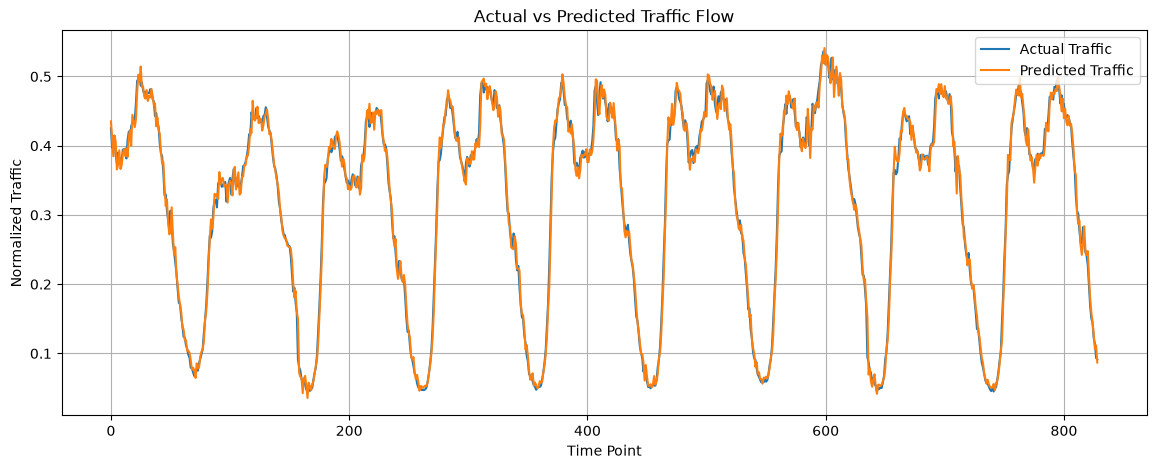

In [9]:
plt.figure(figsize=(14, 5))

plt.plot(y_test, label="Actual Traffic")
plt.plot(y_pred, label="Predicted Traffic")

plt.title("Actual vs Predicted Traffic Flow")
plt.xlabel("Time Point")
plt.ylabel("Normalized Traffic")
plt.legend()
plt.grid(True)
plt.show()

## 9. Future Traffic Prediction

In [10]:
last_sequence = test_traffic[-WINDOW_SIZE:]

next_prediction = model.predict(
    last_sequence.reshape(1, -1)
)[0]

print("Last 10 traffic values:")
print(last_sequence)

print("\nPredicted Next Traffic Value:")
print(next_prediction)

Last 10 traffic values:
[0.24147595 0.22799574 0.19882973 0.1685609  0.15029322 0.14442888
 0.12207432 0.11361513 0.09353106 0.09139032]

Predicted Next Traffic Value:
0.08321740360162172


## 10. Save Traffic Forecasting Model

In [11]:
import joblib

joblib.dump(model, "traffic_forecasting_model.pkl")

print("Traffic forecasting model saved successfully!")

Traffic forecasting model saved successfully!


# Traffic Flow Forecasting using Machine Learning

## Project Overview

This project uses historical traffic flow data from multiple traffic locations to build a machine learning model for forecasting future traffic flow.

The traffic data from 36 locations was aggregated into an overall traffic-flow time series. A Linear Regression model was then trained using the previous 10 time points to predict the next traffic value.

## Dataset

- Training locations: 36
- Training time points: 1,260
- Testing time points: 839
- Forecasting window: 10 previous time points
- Target: Next traffic-flow value

## Data Processing

- Loaded training and testing traffic data.
- Removed the CSV index column.
- Aggregated traffic across 36 locations using the mean.
- Created time-series sequences using a 10-step window.

## Machine Learning Model

**Model:** Linear Regression

The model uses the previous 10 traffic-flow values as input features to predict the next traffic-flow value.

## Model Performance

| Metric | Result |
|---|---:|
| MAE | 0.01007 |
| RMSE | 0.01311 |
| R² Score | 0.99174 |

The model achieved an R² score of approximately **99.17%** on the test data.

## Future Prediction

The model was used to predict the next traffic-flow value using the most recent 10 observations.

**Predicted next normalized traffic value:** 0.08322

## Visualizations

The project includes:

- Traffic flow over time
- Actual vs predicted traffic flow

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Jupyter Notebook

## Project Files

- `Traffic Flow Forecasting.ipynb` — Complete analysis and model development
- `traffic_forecasting_model.pkl` — Trained Linear Regression model

## Future Improvements

- Compare Linear Regression with Random Forest and other forecasting models.
- Incorporate individual traffic locations instead of aggregation.
- Use the adjacency matrix to model relationships between traffic locations.
- Experiment with advanced time-series and deep learning approaches such as LSTM.